First, we are running an ADF test to see if the data is stationary or not. 

In [21]:
import pandas as pd
import numpy as np

# Load and Clean the Main DataFrame ---

df = pd.read_csv('finance_economics_dataset.csv')

# Clean all column names for consistency
df.columns = df.columns.str.strip().str.replace('\ufeff', '').str.title()


# Define Column and Index Names ---
# VERIFY THESE NAMES against the output from the print statements above.
# You may need to change 'Stock Index' or 'Close' to match your file exactly.
date_col = 'Date'
index_name_col = 'Stock Index'  # The column identifying which index it is
value_col = 'Close'             # The column with the actual stock price


# Filter to Create a New DataFrame for Each Stock Index ---

# Ensure the Date column is in datetime format
df[date_col] = pd.to_datetime(df[date_col])

# Create the NASDAQ DataFrame by filtering rows
nasdaq_df = df[df[index_name_col] == 'NASDAQ'].copy()
nasdaq_df.dropna(inplace=True)

# Create the S&P 500 DataFrame by filtering rows
sp500_df = df[df[index_name_col] == 'S&P 500'].copy()
sp500_df.dropna(inplace=True)

# Create the Dow Jones DataFrame by filtering rows
dowjones_df = df[df[index_name_col] == 'Dow Jones'].copy()
dowjones_df.dropna(inplace=True)

In [22]:
from statsmodels.tsa.stattools import adfuller

# 1. Define the ADF Test Function
def perform_adf_test(series, name="Time Series"):
    print(f"\n--- Augmented Dickey-Fuller Test: {name} ---")
    
    # Check if the series is empty before running
    if series.empty:
        print(f"Error: The data for {name} is empty.")
        print(f"Check your spelling: Is it '{name}' or something else in the CSV?")
        return

    result = adfuller(series, autolag='AIC')
    p_value = result[1]
    
    print(f"p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Result: STATIONARY (Use ARMA)")
    else:
        print("Result: NON-STATIONARY (Use ARIMA)")

# 2. Run the tests using 'value_col' (which is 'Close')
# We use .copy() to ensure we don't run into SettingWithCopy warnings later

# print(nasdaq_df.columns)
value_col = 'Close Price'

perform_adf_test(nasdaq_df[value_col], name="NASDAQ")
perform_adf_test(sp500_df[value_col], name="S&P 500")
perform_adf_test(dowjones_df[value_col], name="Dow Jones")


--- Augmented Dickey-Fuller Test: NASDAQ ---
p-value: 0.0000
Result: STATIONARY (Use ARMA)

--- Augmented Dickey-Fuller Test: S&P 500 ---
p-value: 0.0000
Result: STATIONARY (Use ARMA)

--- Augmented Dickey-Fuller Test: Dow Jones ---
p-value: 0.0000
Result: STATIONARY (Use ARMA)


In [23]:
np.random.seed(57) # Set seed for reproducible results
dates = pd.date_range(start='2020-01-01', periods=200)

# Case A: Stationary Data (White Noise)
# Just random numbers jumping around 0. Mean and variance are constant.
stationary_values = np.random.normal(0, 1, 200)
df_stationary = pd.DataFrame({'Date': dates, 'Close Price': stationary_values})

# Case B: Non-Stationary Data (Random Walk)
# The cumulative sum of random numbers. Today depends on yesterday.
# This creates a "drunkard's walk" trend.
non_stationary_values = np.cumsum(np.random.normal(0, 1, 200))
df_non_stationary = pd.DataFrame({'Date': dates, 'Close Price': non_stationary_values})

# --- 3. Run the Verification ---
print("VERIFICATION RUN:")
print("-----------------")

# Test 1: Should be STATIONARY
perform_adf_test(df_stationary['Close Price'], name="Dummy Stationary Data")

# Test 2: Should be NON-STATIONARY
perform_adf_test(df_non_stationary['Close Price'], name="Dummy Trending Data")

VERIFICATION RUN:
-----------------

--- Augmented Dickey-Fuller Test: Dummy Stationary Data ---
p-value: 0.0000
Result: STATIONARY (Use ARMA)

--- Augmented Dickey-Fuller Test: Dummy Trending Data ---
p-value: 0.6602
Result: NON-STATIONARY (Use ARIMA)


According to the ADF test, all of the data from the stock indexes are stationary. This means we will essentially be using an ARMA model. 

In [24]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# We will start with NASDAQ 
train_nasdaq = nasdaq_df.set_index('Date')['Close Price']

Data loaded: 1036 rows for S&P 500
Applying Log transform...
Train size: 828
Test size:  208

Spinning up ARIMA(10, 1, 0)...
Generating forecast...
Converting logs back to dollar prices...

--- Scorecard ---
MAE:  $1316.95
RMSE: $1632.73
MAPE: 0.3913 (Off by about 39.13%)


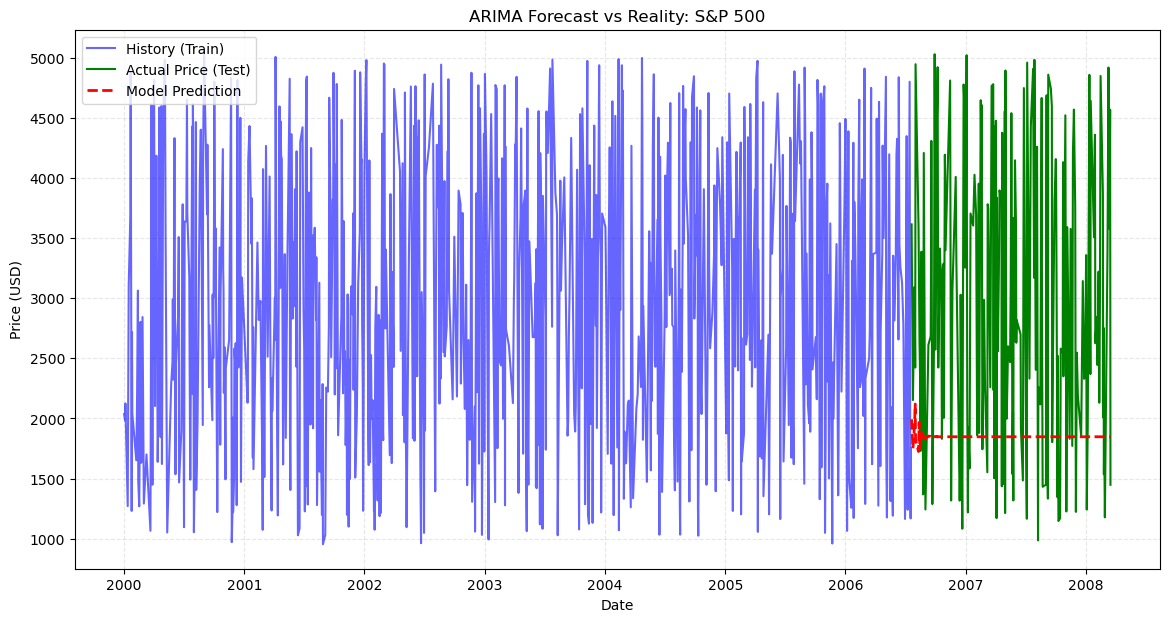

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

target_index_name = "S&P 500"
data = sp500_df.copy() 

if data.empty:
    print(f"Error: No data found for {target_index_name}.")
else:
    print(f"Data loaded: {len(data)} rows for {target_index_name}")

# --- 2. Filter and Prepare Time Series ---

if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

try:
    # Safely select the column
    ts_data = data[value_col]
except KeyError:
    fallback_col = 'Close' if value_col == 'Close Price' else 'Close Price'
    if fallback_col in data.columns:
        ts_data = data[fallback_col]
    else:
        raise

# Force numeric and drop NaNs
ts_data = pd.to_numeric(ts_data, errors='coerce').dropna().sort_index()

# --- FIX: Bypass Index/Frequency Issues ---
# We extract the values and reset the index to simple integers (0, 1, 2...)
# This prevents ARIMA from crashing on holidays or missing business days.
ts_values = ts_data.values
ts_dates = ts_data.index # Save dates for plotting later

# --- TOGGLE: Log Transformation ---
USE_LOG_TRANSFORM = True

if USE_LOG_TRANSFORM:
    print("Applying Log transform...")
    # Handle potential zeros before log
    ts_modeling = np.log(ts_values)
else:
    ts_modeling = ts_values

# --- 3. Train/Test Split ---
train_size = int(len(ts_modeling) * 0.8)

# Split the values (for the model)
train_data, test_data = ts_modeling[:train_size], ts_modeling[train_size:]

# Split the dates (for the plot)
train_dates, test_dates = ts_dates[:train_size], ts_dates[train_size:]

print(f"Train size: {len(train_data)}")
print(f"Test size:  {len(test_data)}")

# --- 4. Build and Train ARIMA Model ---
# Restored to original non-seasonal parameters
p = 10  # Lag: Look back 1 week
d = 1  # Trend: 1 means we difference the data to remove the trend
q = 0  # Shock: 0 for simple baseline

arima_order = (p, d, q)

print(f"\nSpinning up ARIMA{arima_order}...")
model = ARIMA(train_data, order=arima_order) # Removed seasonal_order
model_fit = model.fit()

# --- 5. Forecast ---
print("Generating forecast...")
forecast_result = model_fit.forecast(steps=len(test_data))

# --- REVERSE LOGS ---
if USE_LOG_TRANSFORM:
    print("Converting logs back to dollar prices...")
    forecast_values = np.exp(forecast_result)
    actual_values = np.exp(test_data)
    train_values_original = np.exp(train_data)
else:
    forecast_values = forecast_result
    actual_values = test_data
    train_values_original = train_data

# --- 6. Evaluation Metrics ---
# We align the forecast with the actuals manually
mae = mean_absolute_error(actual_values, forecast_values)
rmse = np.sqrt(mean_squared_error(actual_values, forecast_values))
mape = mean_absolute_percentage_error(actual_values, forecast_values)

print("\n--- Scorecard ---")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.4f} (Off by about {mape*100:.2f}%)")

# --- 7. Visualization ---
plt.figure(figsize=(14, 7))

# Plot History
plt.plot(train_dates, train_values_original, label='History (Train)', color='blue', alpha=0.6)

# Plot Reality
plt.plot(test_dates, actual_values, label='Actual Price (Test)', color='green')

# Plot Prediction (aligned with test dates)
plt.plot(test_dates, forecast_values, label='Model Prediction', color='red', linestyle='--', linewidth=2)

plt.title(f'ARIMA Forecast vs Reality: {target_index_name}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()